In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================

# Load Woolworths dataset
df = pd.read_csv(
    '/content/Aus_Woolies_3.csv',
    low_memory=False
)

print(f"Original rows: {len(df):,}")
# ------------------------------------------------------------
# SELECT REQUIRED COLUMNS
# ------------------------------------------------------------

final_columns = [

    'Sku',
    'Name',

    'RunDate',

    'unit_price_x',

    'was_price_x',

    'is_on_special_x',

    'savings_amount_x'

]

df_model = df[
    final_columns
].copy()

# ------------------------------------------------------------
# DATE CONVERSION
# ------------------------------------------------------------

df_model['RunDate'] = pd.to_datetime(
    df_model['RunDate'],
    format='mixed',
    errors='coerce'
)

# Remove invalid dates
df_model = df_model.dropna(
    subset=['RunDate']
)

# ------------------------------------------------------------
# DEDUPLICATION
# Keep latest observation per SKU per day
# ------------------------------------------------------------

df_model['Date'] = (
    df_model['RunDate']
    .dt.date
)

df_daily = (

    df_model

    .sort_values(
        'RunDate'
    )

    .groupby(
        ['Sku', 'Date']
    )

    .last()

    .reset_index()

)

# ------------------------------------------------------------
# SORT DATA
# ------------------------------------------------------------

df_daily = df_daily.sort_values(

    ['Sku', 'RunDate']

)

# ------------------------------------------------------------
# DATA SUMMARY
# ------------------------------------------------------------

print(
    f"Rows after deduplication: "
    f"{len(df_daily):,}"
)

print(
    "Unique products:",
    df_daily['Sku'].nunique()
)

print(

    "Date range:",

    df_daily['RunDate']
    .min()
    .date(),

    "to",

    df_daily['RunDate']
    .max()
    .date()

)

print(
    "\nSample data:"
)

display(
    df_daily.head()
)

,Category,Sub_category,Product_Group,Product_Name,Brand,Sku,RunDate,unit_price_x
0,Meat & seafood,Poultry,Chicken offal,RSPCA Approved Chicken Necks,Coles,1491280P,11/9/2022,6.50
1,Meat & seafood,Poultry,Chicken offal,RSPCA Approved Chicken Livers,Coles,1718058P,11/9/2022,9.00
2,Meat & seafood,Poultry,Chicken offal,RSPCA Approved Chicken Giblets,Coles,2565429P,11/9/2022,7.50
3,Meat & seafood,Poultry,Chicken offal,RSPCA Approved Chicken Frames,Coles,3199541P,11/9/2022,4.50
4,Meat & seafood,Poultry,Crumbed chicken,RSPCA Chicken Schnitzel Plain Crumb,Coles,2904193P,11/9/2022,8.75


In [10]:
df = df[(df['unit_price_x'] != 0) & (df['unit_price_x'].notna())]

In [11]:
# Parse date
df['RunDate'] = pd.to_datetime(df['RunDate'], dayfirst=True, errors='coerce')

# Sort properly
df = df.sort_values(['Sku', 'RunDate'])

AGGREGATE (1 price per product per day)

In [12]:
df_daily = (
    df.groupby(['Sku', 'RunDate'])['unit_price_x']
    .mean()
    .reset_index()
)

Feauture Engineering

In [18]:
def create_features(df):

    df = df.copy()

    # -------------------------
    # TIME FEATURES
    # -------------------------
    df['day_of_week'] = df['RunDate'].dt.dayofweek
    df['month'] = df['RunDate'].dt.month
    df['day_of_month'] = df['RunDate'].dt.day

    # Weekend feature
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Encode SKU
    df['Sku'] = df['Sku'].astype('category').cat.codes

    # -------------------------
    # LAG FEATURES
    # -------------------------
    for lag in [1, 2, 3, 7, 14]:
        df[f'lag_{lag}'] = (
            df.groupby('Sku')['unit_price_x']
            .shift(lag)
        )

    # -------------------------
    # ROLLING MEANS
    # -------------------------
    df['rolling_mean_7'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(1)
        .rolling(7)
        .mean()
    )

    df['rolling_mean_14'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(1)
        .rolling(14)
        .mean()
    )

    df['rolling_mean_30'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(1)
        .rolling(30)
        .mean()
    )

    # -------------------------
    # ROLLING STD
    # -------------------------
    df['rolling_std_7'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(1)
        .rolling(7)
        .std()
    )

    # -------------------------
    # MIN / MAX FEATURES
    # -------------------------
    df['rolling_min_7'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(1)
        .rolling(7)
        .min()
    )

    df['rolling_max_7'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(1)
        .rolling(7)
        .max()
    )

    # -------------------------
    # PRICE CHANGES
    # -------------------------
    df['price_change_1'] = (
        df['unit_price_x'] - df['lag_1']
    )

    df['price_change_7'] = (
        df['unit_price_x'] - df['lag_7']
    )

    # -------------------------
    # DISCOUNT FEATURE
    # -------------------------
    df['discount_percent'] = (
        (
            df['rolling_mean_30'] - df['unit_price_x']
        )
        / df['rolling_mean_30']
    ) * 100

    # -------------------------
    # FUTURE TARGET
    # Predict 7 days ahead
    # -------------------------
    df['future_price'] = (
        df.groupby('Sku')['unit_price_x']
        .shift(-7)
    )

    return df

In [19]:
df_features = create_features(df_daily)

# Fill missing feature values
df_features = df_features.bfill()

# Remove rows without future target
df_features = df_features.dropna(
    subset=['future_price']
)

# Replace remaining NaNs
df_features = df_features.fillna(0)

Defining the features and Target

In [20]:
feature_cols = [

    'Sku',

    'day_of_week',
    'month',
    'day_of_month',
    'is_weekend',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7',
    'lag_14',

    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',

    'rolling_std_7',

    'rolling_min_7',
    'rolling_max_7',

    'price_change_1',
    'price_change_7',

    'discount_percent'
]

X = df_features[feature_cols]
y = df_features['future_price']

Train/test split

In [21]:
total_rows = len(df_features)
print("Rows after feature engineering:", total_rows)

if total_rows < 20:
    raise ValueError("Too little data after feature engineering")

split = int(total_rows * 0.8)

# Ensure test set exists
if total_rows - split < 10:
    split = total_rows - 10

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Rows after feature engineering: 24205
Train size: 19364
Test size: 4841


Training the XGBoost Model

In [22]:
model = XGBRegressor(

    n_estimators=800,
    learning_rate=0.02,

    max_depth=8,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=2,

    objective='reg:squarederror',

    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
# Predictions
y_pred = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("====================================")
print("XGBOOST RESULTS")
print("====================================")
print(f"XGB MAE  : {mae:.4f}")
print(f"XGB RMSE : {rmse:.4f}")
print(f"XGB R2   : {r2:.4f}")


XGBOOST RESULTS
XGB MAE  : 3.6559
XGB RMSE : 5.0056
XGB R2   : 0.7431


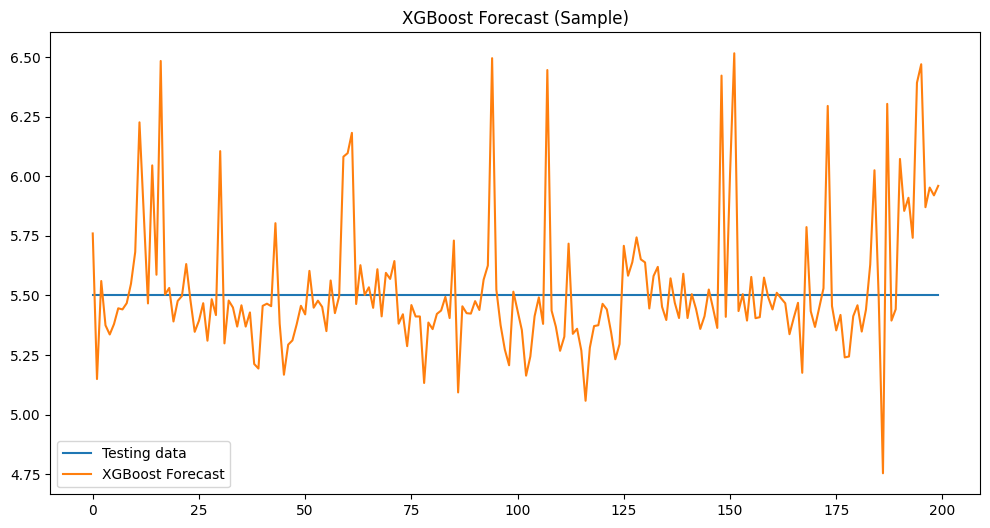

In [25]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Testing data')
plt.plot(y_pred[:200], label='XGBoost Forecast')
plt.legend()
plt.title("XGBoost Forecast (Sample)")
plt.show()

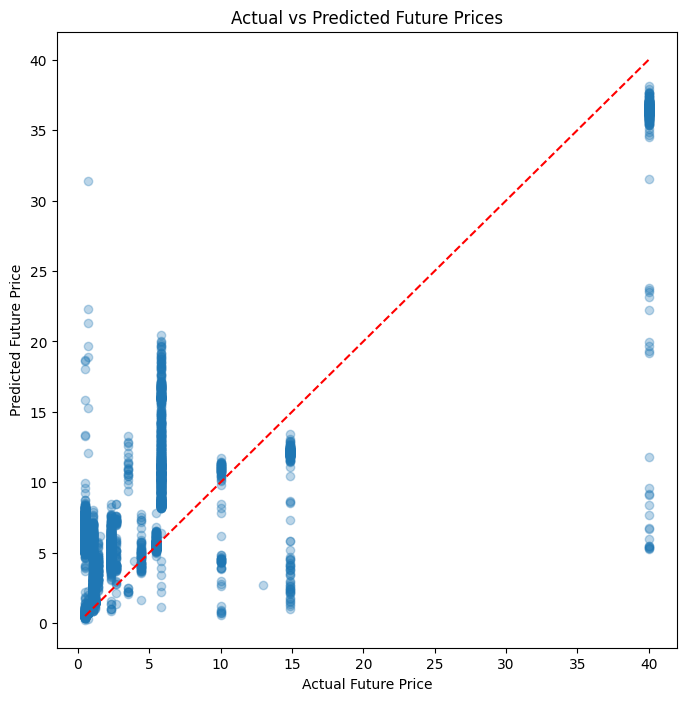

In [26]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Future Price")
plt.ylabel("Predicted Future Price")

plt.title("Actual vs Predicted Future Prices")

plt.show()

Error Distribution

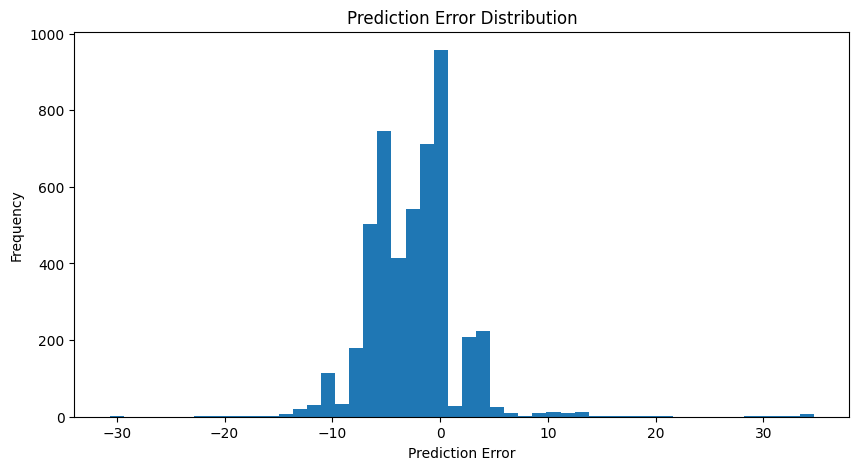

In [27]:
#Error Distribution
errors = y_test - y_pred

plt.figure(figsize=(10,5))

plt.hist(errors, bins=50)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

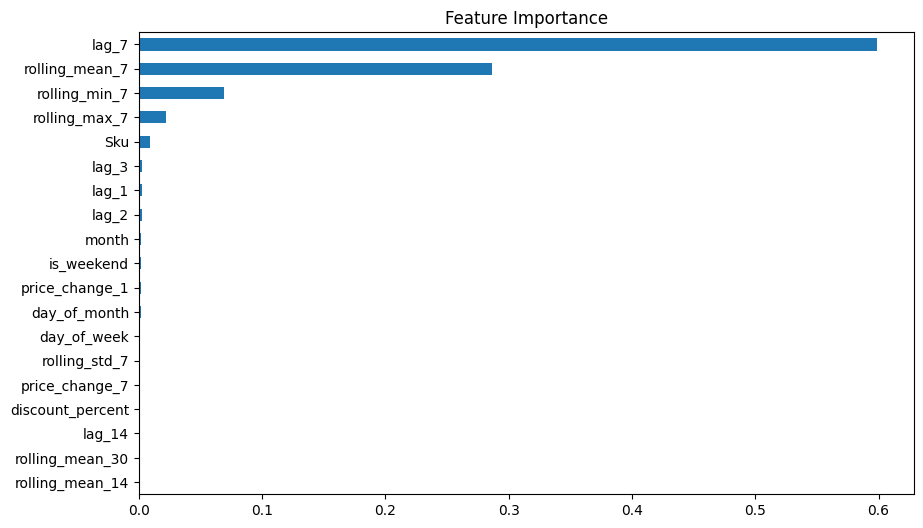

In [28]:
#Feature Importance
importance = model.feature_importances_

feat_imp = pd.Series(
    importance,
    index=feature_cols
)

feat_imp = feat_imp.sort_values()

plt.figure(figsize=(10,6))

feat_imp.plot(kind='barh')

plt.title("Feature Importance")

plt.show()

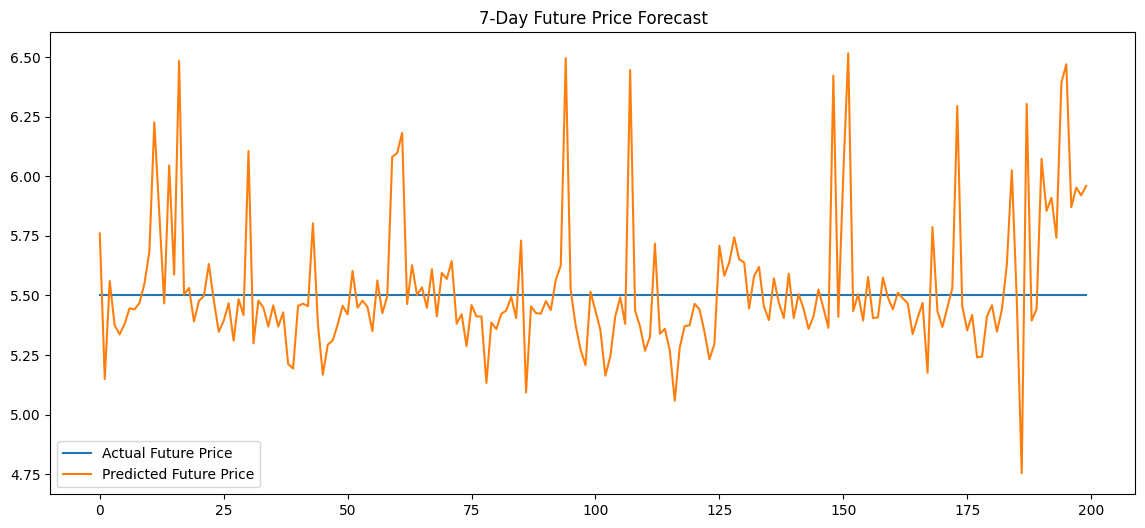

In [29]:
#Future Price Forecast
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual Future Price'
)

plt.plot(
    y_pred[:200],
    label='Predicted Future Price'
)

plt.legend()

plt.title("7-Day Future Price Forecast")

plt.show()

In [30]:
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

print("\nTop Features:")
print(importance.head(10))


Top Features:
lag_7             0.598811
rolling_mean_7    0.286128
rolling_min_7     0.069028
rolling_max_7     0.021953
Sku               0.008609
lag_3             0.002433
lag_1             0.002121
lag_2             0.002057
month             0.001696
is_weekend        0.001656
dtype: float32


In [31]:
with open('discountmate_xgboost.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!
